# **Capstone Project Data Scientist - SplitMate**

## Mengumpulkan dan menganalisis permasalahan
Generasi Z (kelahiran 1997-2012) saat ini berada dalam fase kehidupan yang penuh dengan aktivitas sosial dan kebersamaan. Mulai dari nongkrong di cafe, makan bersama, liburan bareng teman, hingga patungan biaya penginapan/kost, semua kegiatan ini melibatkan transaksi keuangan bersama. Namun, berdasarkan survei dan observasi umum, ditemukan 4 masalah utama, yaitu:
- Pencatatan Patungan Masih Manual & Berantakan: saat ini banyak anak muda yang mencatat patungan dan utang melalui chat WhatsApp yang terkubur dan susah dicari, catatan di Notes ponsel yang tidak terstruktur, atau dibayar dulu satu orang lalu berharap diingat yang lain, sehingga dampaknya banyak tagihan yang lupa dibayar, hubungan pertemanan retak karena masalah uang, dan biasanya satu orang sering menanggung beban lebih besar.
- Tidak Ada Visibilitas Pola Pengeluaran: saat ini generasi Z cenderung melakukan banyak transaksi kecil yang tidak teras seperti beli kopi setiap hari, transportasi online (Rp 20-30 ribu per trip), dan jajan snack (Rp 10-20 ribu). Tanpa adanya pencatatan yang baik, maka mereka tidak tahu kemana uangnya pergi,kaget saat melihat saldo menipis di akhir bulan, dan tidak bisa mengidentifikasi kategori pengeluaran terbesar.
- Utang Piutang Antar Teman Tidak Terkelola: dalam pertemanan, aktivitas pinjam-meminjam uang sangat umum terjadi seperti "titip beli tiket dulu ya", "pinjam dulu 100 ribu, ganti mingdep", atau "bayarin makan dulu, aku transfer nanti". Namun, realitanya adalah tidak ada sistem yang mencatat siapa berhutang kepada siapa, pengingat hutang dianggap "kepo" atau "pelit", ataupun banyak hutang kecil yang terlupakan dan akhirnya jadi "hilang".
- Tidak Ada Perencanaan Keuangan Masa Depan: sebagian besar generasi muda belum memiliki kebiasaan perencanaan keuangan, seperti tidak tahu berapa perkiraan pengeluaran bulan depan, tidak punya target tabungan, tidak ada peringatan dini jika pengeluaran sudah melebihi batas. Akibatnya adalah sering merasa saldo menipis di pertengahan bulan, tidak siap dengan pengeluaran tak terduga, dan sulit menabung untuk tujuan jangka panjang.

Selain membantu pencatatan transaksi dan pengelolaan utang, SplitMate juga memanfaatkan teknologi machine learning untuk memberikan insight keuangan yang lebih cerdas. Sistem dikembangkan untuk melakukan klasifikasi kategori pengeluaran secara otomatis serta memprediksi pengeluaran pengguna berdasarkan riwayat transaksi, sehingga pengguna dapat memahami kondisi finansialnya dengan lebih baik.

Oleh karena itu, dibutuhkan sebuah solusi yang mampu membantu pengguna dalam mencatat transaksi patungan, memahami pola pengeluaran, serta mengelola hubungan utang-piutang secara lebih terstruktur. SplitMate hadir sebagai solusi untuk menjawab permasalahan tersebut dengan menyediakan sistem pengelolaan keuangan yang lebih terintegrasi, sehingga pengguna dapat tetap menjalani aktivitas sosialnya tanpa mengabaikan kondisi keuangan mereka.

## Pertanyaan Bisnis
- Bagaimana tren perbandingan antara income dan expense pengguna per bulan selama periode Januari 2021 hingga Desember 2024, serta pada bulan apa pengeluaran melebihi pemasukan?
- Bagaimana distribusi persentase pengeluaran berdasarkan kategori setiap bulan selama periode Januari 2021 hingga Desember 2024, dan kategori apa yang secara konsisten menjadi penyumbang terbesar?
- Sejauh mana setiap user_id mengalami kondisi defisit (cashflow negatif) selama periode Januari 2021 hingga Desember 2024, berdasarkan selisih total income dan expense, dan berapa proporsi user yang mengalami kondisi tersebut?
- Metode pembayaran apa yang paling sering digunakan selama periode Januari 2021 hingga Desember 2024, serta bagaimana kontribusinya terhadap total dan rata-rata nilai transaksi?
- Bagaimana pola kemunculan transaksi bernilai tinggi (high spending), yang didefinisikan sebagai transaksi di atas persentil ke-75, berdasarkan waktu selama periode Januari 2021 hingga Desember 2024?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

## Data Wrangling

### Gathering Data

In [ ]:
#Membaca file
df_finance = pd.read_csv("budgetwise_finance_dataset.csv")
df_finance.head()


,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T4999,U018,2023-04-25,Expense,Educaton,3888,card,Ahmedabad,Movie tickets
1,T12828,U133,08/05/2022,Expense,rent,649,NaN,Hyderabad,asdfgh
2,T7403,U091,31-12-23,Income,Freelance,13239,Csh,BAN,Books
3,T12350,U097,NaN,Expense,Fod,6299,Bank Transfer,AHMEDABAD,Electricity bill
4,T7495,U088,10/28/2022,Expense,entertainment,2287,CARD,Hyderabad,NaN


### Assessing Data

In [ ]:
#Untuk cek struktur data
df_finance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    15900 non-null  object
 1   user_id           15900 non-null  object
 2   date              15414 non-null  object
 3   transaction_type  15900 non-null  object
 4   category          15615 non-null  object
 5   amount            15609 non-null  object
 6   payment_mode      15092 non-null  object
 7   location          14638 non-null  object
 8   notes             13079 non-null  object
dtypes: object(9)
memory usage: 1.1+ MB


In [ ]:
#Cek apakah ada missing value
df_finance.isna().sum()

,0
transaction_id,0
user_id,0
date,486
transaction_type,0
category,285
amount,291
payment_mode,808
location,1262
notes,2821


In [ ]:
#Cek apakah ada ducplicate data secara keseluruhan
df_finance.duplicated().sum()

np.int64(900)

In [ ]:
#Cek apakah ada ducplicate data pada transaction_id (karena seharusnya unik)
df_finance['transaction_id'].duplicated().sum()

np.int64(1900)

In [ ]:
df_finance[df_finance['transaction_id'].duplicated(keep=False)].sort_values('transaction_id')

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
4281,T0003,U097,24-08-22,Expense,health,850,Card,ahmedabad,misc
7403,T0003,U078,2021-08-26,Income,Others,64935,Bank Transfer,LUC,!!!
180,T0010,U017,04/19/2024,Expense,NaN,1064,csh,AHM,Books
11775,T0010,U081,03/20/2024,Expense,Rnt,5421,UPI,DELHI,Internet bill
4189,T0011,U147,13-05-22,Expense,Food,2952,Cash,hyderabad,Movie tickets
...,...,...,...,...,...,...,...,...,...
6770,T9966,U121,2024-12-20,Expense,Foods,1842,CARD,Ahmedabad,test
13771,T9972,U127,18-05-21,Expense,Helth,-1000,Crd,NaN,Medicine
7904,T9972,U025,2023-02-26,Expense,Educaton,8254,CARD,PUN,Fixed deposit
1579,T9979,U072,03/04/2024,Expense,Other,5126,BankTransfer,Lucknow,Books


In [ ]:
#Mengubah semua huruf menjadi kecil, menghapus spasi depan/belakang
cols = ['transaction_type','category', 'payment_mode', 'location', 'notes']

for col in cols:
    df_finance[col] = df_finance[col].str.lower().str.strip()

In [ ]:
#Cek nilai unik dan inkosistensi
for col in ['transaction_type','category','payment_mode','location','notes']:
    print(f"\n{col}:")
    print(df_finance[col].unique())


transaction_type:
['expense' 'income']

category:
['educaton' 'rent' 'freelance' 'fod' 'entertainment' 'foods' 'education'
 'salary' 'utilties' 'others' 'utility' 'utlities' 'rentt' 'food' 'travel'
 'health' 'travl' 'investment' 'foodd' 'helth' 'utilities' 'rnt' 'savings'
 'edu' 'traval' nan 'bonus' 'entertain' 'saving' 'entrtnmnt' 'misc'
 'other']

payment_mode:
['card' nan 'csh' 'bank transfer' 'crd' 'upi' 'banktransfer'
 'bank_transfer' 'bank transfr' 'cash']

location:
['ahmedabad' 'hyderabad' 'ban' nan 'lucknow' 'ahm' 'kol' 'luc' 'del'
 'bangalore' 'chennai' 'pune' 'che' 'jaipur' 'jai' 'delhi' 'kolkata' 'mum'
 'mumbai' 'hyd' 'pun']

notes:
['movie tickets' 'asdfgh' 'books' 'electricity bill' nan 'test'
 'uber ride' '...' 'grocery shopping' 'gym membership' 'restaurant dinner'
 'atm withdrawal' 'xyz123' 'misc' 'doctor consultation' 'coffee'
 'shopping' 'internet bill' 'online course' 'train ticket' '!!!'
 'medicine' 'emi payment' 'petrol' 'monthly rent payment' 'fixed deposit'
 'l

In [ ]:
#Cek dengan statistik deskriptif
df_finance.describe()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
count,15900,15900,15414,15900,15615,15609,15092,14638,13079
unique,14000,150,5025,2,31,11165,9,20,26
top,T8639,U036,2024-08-13,expense,food,999999,upi,pune,electricity bill
freq,5,136,14,13517,1729,80,3660,1132,561


### Cleaning Data

In [ ]:
#Mengubah tipe data date ke datetime
df_finance['date'] = pd.to_datetime(df_finance['date'], errors='coerce')

#Membuat kolom tambahan berdasarkan date
df_finance['year_month'] = df_finance['date'].dt.to_period('M')
df_finance['month'] = df_finance['date'].dt.month
df_finance['day_of_week'] = df_finance['date'].dt.day_name()
df_finance['is_weekend'] = df_finance['day_of_week'].isin(['Saturday', 'Sunday'])

#Cek missing value berdasarkan date
df_finance['date'].isna().sum()

np.int64(9809)

In [ ]:
#Cek tipe data date
df_finance['date'].dtype

dtype('<M8[ns]')

In [ ]:
#Menyimpan data amount asli sebelum dibersihkan
df_finance['amount_raw'] = df_finance['amount'].astype(str)

#Membuat default currency menjadi INR
df_finance['currency'] = 'INR'

#Mengubah currency menjadi USD jika terdapat simbol $
df_finance.loc[
    df_finance['amount_raw'].str.contains(r'\$', na=False),
    'currency'
] = 'USD'

#Mengubah currency menjadi INR jika terdapat simbol ₹ atau Rs.
df_finance.loc[
    df_finance['amount_raw'].str.contains(r'₹|Rs\.', na=False),
    'currency'
] = 'INR'

#Menghapus simbol mata uang pada kolom amount
df_finance['amount'] = (
    df_finance['amount_raw']
    .str.replace(r'₹|\$|Rs\.', '', regex=True)
    .str.replace(',', '')
    .str.strip()
)

In [ ]:
#Mengubah tipe data amount menjadi numerik
df_finance['amount'] = pd.to_numeric(
    df_finance['amount'],
    errors='coerce'
)

In [ ]:
#Cek invalid_value pada amount
df_finance['amount'].value_counts()

,count
amount,
999999.0,91
999999999.0,82
0.0,79
-500.0,75
-1000.0,75
...,...
871.0,1
8559.0,1
77543.0,1


In [ ]:
#Cek tanda negative pada amount
df_finance[df_finance['amount'] < 0][[
    'transaction_type',
    'amount',
    'category'
]]

,transaction_type,amount,category
629,expense,-1000.0,rentt
655,expense,-1000.0,fod
713,expense,-500.0,rent
732,expense,-1000.0,fod
785,expense,-500.0,travl
...,...,...,...
14894,expense,-1000.0,entrtnmnt
15342,expense,-1000.0,travel
15547,expense,-1000.0,foods
15765,expense,-500.0,food


In [ ]:
#Menghilangkan tanda negative
df_finance['amount'] = df_finance['amount'].abs()

df_finance[df_finance['amount'] < 0][[
    'transaction_type',
    'amount',
    'category'
]]

,transaction_type,amount,category


In [ ]:
#Ambil data berdasarkan tahun
df_finance['year'] = df_finance['date'].dt.year

kurs_tahun = {
    2021: {'USD': 14300, 'INR': 193},
    2022: {'USD': 14800, 'INR': 188},
    2023: {'USD': 15200, 'INR': 184},
    2024: {'USD': 15900, 'INR': 190}
}

#Fungsi untuk menentukan nilai kurs
def convert_to_idr(row):
    year = row['year']
    currency = row['currency']
    amount = row['amount']

    if year in kurs_tahun:
        rate = kurs_tahun[year].get(currency)
        if rate:
            return amount * rate
    return None

#Hapus invalid value
invalid_values = [999999, 999999999]

df_finance = df_finance[
    ~df_finance['amount'].isin(invalid_values)
]

#Konversi ke IDR
df_finance['amount_idr'] = (
    df_finance.apply(convert_to_idr, axis=1)
)

In [ ]:
#Menghapus data yang tidak valid, seperti tanggal tidak ada, ataupun amount
df_finance = df_finance.dropna(subset=['date', 'amount'])

In [ ]:
#Menangani missing value
df_finance = df_finance.fillna({
    "payment_mode": "unknown",
    "location": "unknown",
    "notes": ""
})

In [ ]:
#Menghapus transaction_id yang duplikat
#Sorting dulu, lalu hanya menyimpan data yang terakhir
df_finance = df_finance.sort_values('date')
df_finance = df_finance.drop_duplicates(subset='transaction_id', keep='last')

In [ ]:
#Menghapus nilai tidak valid jika amount = 0
df_finance = df_finance[df_finance['amount'] > 0]

In [ ]:
#Melakukakn mapping pada kolom category
category_map = {
    'educaton':'education','edu':'education',
    'foods':'food','foodd':'food','fod':'food',
    'entrtnmnt':'entertainment','entertain':'entertainment',
    'helth':'health',
    'traval':'travel','travl':'travel',
    'utility':'utilities','utilties':'utilities','utlities':'utilities',
    'rnt':'rent','rentt':'rent',
    'others':'other',
    'saving':'savings',
    'unknown': None,
    'misc': None
}
df_finance['category'] = df_finance['category'].replace(category_map)

In [ ]:
#Cek proporsi other
df_finance['category'].value_counts(normalize=True)

,proportion
category,
food,0.219650
rent,0.168872
travel,0.128794
utilities,0.102335
entertainment,0.087160
education,0.064786
other,0.040856
health,0.040661
investment,0.031128


In [ ]:
#Melakukakn mapping pada kolom payment
df_finance['payment_mode'] = df_finance['payment_mode'].replace({
    'crd':'card','csh':'cash',
    'bank transfr':'bank_transfer',
    'banktransfer':'bank_transfer',
    'bank transfer':'bank_transfer'
})

In [ ]:
#Melakukakn mapping pada kolom location
location_map = {
    'mum':'mumbai','ban':'bengaluru','bangalore':'bengaluru',
    'jai':'jaipur','che':'chennai','hyd':'hyderabad',
    'pun':'pune','kol':'kolkata','del':'delhi',
    'luc':'lucknow','ahm':'ahmedabad'
}
df_finance['location'] = df_finance['location'].replace(location_map)

In [ ]:
#Melakukakn mapping pada kolom notes
noise = ['xyz123','asdfgh','test','!!!','...','']

df_finance['notes'] = (
    df_finance['notes']
    .replace(noise, None)
    .fillna('unknown')
    .str.lower()
    .str.strip()
)

In [ ]:
#Cek missing value semua kolom
df_finance.isna().sum()

,0
transaction_id,0
user_id,0
date,0
transaction_type,0
category,114
amount,0
payment_mode,0
location,0
notes,0
year_month,0


In [ ]:
#Melihat baris missing value pada kolom category
df_finance[df_finance['category'].isna()]

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,amount_raw,currency,year,amount_idr
8738,T4733,U063,2021-01-19,expense,NaN,7401.0,cash,delhi,unknown,2021-01,1.0,Tuesday,False,7401,INR,2021.0,1428393.0
13275,T7526,U054,2021-01-25,income,NaN,33737.0,upi,unknown,gym membership,2021-01,1.0,Monday,False,33737,INR,2021.0,6511241.0
9675,T1776,U138,2021-02-03,expense,None,4566.0,cash,ahmedabad,unknown,2021-02,2.0,Wednesday,False,$4566,USD,2021.0,65293800.0
8373,T4850,U016,2021-02-09,expense,NaN,4687.0,cash,hyderabad,gym membership,2021-02,2.0,Tuesday,False,4687,INR,2021.0,904591.0
108,T5936,U022,2021-06-13,expense,NaN,6856.0,unknown,chennai,shopping,2021-06,6.0,Sunday,True,₹6856,INR,2021.0,1323208.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,T2483,U084,2024-11-28,expense,NaN,3386.0,card,unknown,unknown,2024-11,11.0,Thursday,False,3386,INR,2024.0,643340.0
11499,T9731,U143,2024-12-11,expense,NaN,2736.0,bank_transfer,lucknow,grocery shopping,2024-12,12.0,Wednesday,False,₹2736,INR,2024.0,519840.0
7769,T8627,U054,2024-12-22,expense,NaN,2837.0,bank_transfer,pune,unknown,2024-12,12.0,Sunday,True,Rs.2837,INR,2024.0,539030.0
7603,T12672,U022,2024-12-23,expense,NaN,2524.0,cash,delhi,unknown,2024-12,12.0,Monday,False,2524,INR,2024.0,479560.0


In [ ]:
#Cek isi notes dari data (category) missing value
df_finance[df_finance['category'].isna()]['notes'].value_counts()

,count
notes,
unknown,49
monthly rent payment,7
misc,6
medicine,6
restaurant dinner,5
grocery shopping,4
movie tickets,4
gym membership,4
lunch,4


In [ ]:
#Isi category yang kosong
#Membersihkan data kosong
df_finance['category'] = df_finance['category'].replace(['', ' '], None)
df_finance['notes'] = df_finance['notes'].replace(['', ' '], None)

#Data yang kosong diambil dari notes, sisanya diisi unknown
df_finance['category'] = df_finance['category'].fillna(df_finance['notes'])
df_finance['category'] = df_finance['category'].fillna('unknown')
df_finance['category'] = df_finance['category'].str.lower().str.strip()

#Membuat keywords
category_keywords = {
    'food': ['food','lunch','restaurant','grocery','dinner','coffee','breakfast','meal','eat','snack'],
    'rent': ['rent'],
    'travel': ['travel','train','uber','taxi','ride','petrol','fuel','gas','flight','transport'],
    'entertainment': ['movie','entertainment','cinema','ticket','game','netflix','shopping'],
    'health': ['gym','health','medicine','doctor','hospital','consultation','clinic'],
    'education': ['education','course','books','school','tuition'],
    'utilities': ['internet','bill','utilities','electricity','water','phone','subscription'],
    'salary': ['salary'],
    'bonus': ['bonus'],
    'freelance': ['freelance'],
    'investment': ['investment','deposit','fixed deposit','interest'],
    'savings': ['saving'],
    'other': ['atm','withdrawal','cash','transfer']
}

#Mapping berdasarkan keywords yang dibuat
def map_category(x):
    x = str(x).lower()

    for category, keywords in category_keywords.items():
        if any(k in x for k in keywords):
            return category

    return 'other'

#Apply mapping
df_finance['category'] = df_finance['category'].apply(map_category)
df_finance['category'] = df_finance['category'].fillna('other')

In [ ]:
df_finance.isna().sum()

,0
transaction_id,0
user_id,0
date,0
transaction_type,0
category,0
amount,0
payment_mode,0
location,0
notes,0
year_month,0


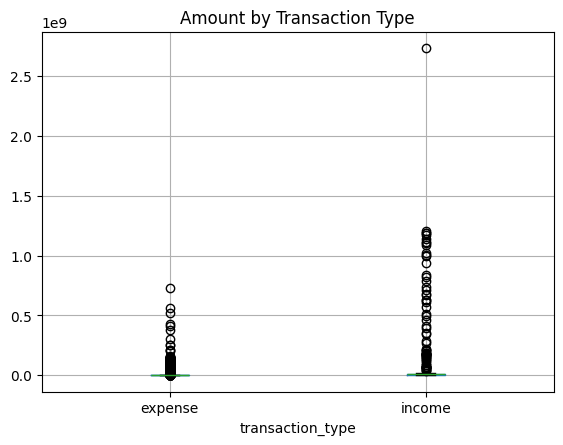

In [ ]:
#Cek sebaran data pada amount_idr berdasarkan transaction_type menggunakan boxplot
df_finance.boxplot(column='amount_idr', by='transaction_type')
plt.title("Amount by Transaction Type")
plt.suptitle("")
plt.show()

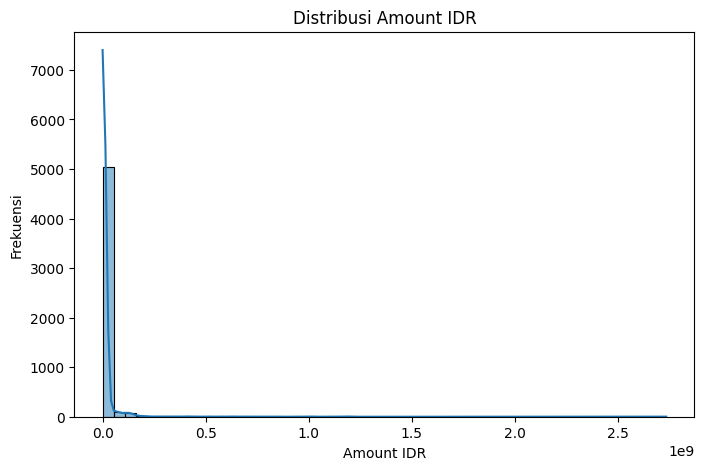

In [ ]:
#Membuat histogram distribusi amount_idr
plt.figure(figsize=(8,5))

sns.histplot(
    df_finance['amount_idr'],
    bins=50,
    kde=True
)

plt.title("Distribusi Amount IDR")
plt.xlabel("Amount IDR")
plt.ylabel("Frekuensi")
plt.show()

**Insight:**

- Histogram menunjukkan bahwa distribusi amount_idr bersifat right-skewed, di mana sebagian besar transaksi memiliki nominal yang relatif kecil dan terkonsentrasi pada nilai rendah.
- Terdapat ekor distribusi yang sangat panjang di sisi kanan grafik, yang menunjukkan adanya sejumlah kecil transaksi dengan nominal sangat besar dibandingkan mayoritas transaksi lainnya.
- Pola ini mengindikasikan bahwa data transaksi tidak terdistribusi normal dan dipengaruhi oleh keberadaan transaksi ekstrem (outlier), sehingga rata-rata (mean) kemungkinan lebih tinggi dibandingkan median.
- Distribusi yang sangat miring ke kanan juga menunjukkan adanya ketidakseimbangan skala data, di mana sebagian besar transaksi berada pada rentang nominal rendah, sementara hanya sedikit transaksi yang memiliki nilai sangat tinggi hingga mencapai miliaran rupiah.

In [ ]:
df_finance.sort_values(
    by='amount_idr',
    ascending=False
)[
    ['date', 'category', 'transaction_type','amount','currency','amount_idr']
].head(20)

,date,category,transaction_type,amount,currency,amount_idr
2482,2022-12-21,freelance,income,184818.0,USD,2.735306e+09
1607,2024-02-10,bonus,income,75823.0,USD,1.205586e+09
4475,2024-10-14,other,income,74866.0,USD,1.190369e+09
4752,2023-05-12,freelance,income,78210.0,USD,1.188792e+09
9822,2022-08-18,investment,income,79300.0,USD,1.173640e+09
12558,2021-05-24,freelance,income,79605.0,USD,1.138352e+09
9862,2024-02-05,salary,income,69864.0,USD,1.110838e+09
1035,2022-05-20,other,income,74525.0,USD,1.102970e+09
2110,2024-11-09,investment,income,68676.0,USD,1.091948e+09
7838,2024-03-11,investment,income,64156.0,USD,1.020080e+09


In [ ]:
df_finance[
    df_finance['transaction_type'] == 'expense'
]['amount_idr'].describe()

,amount_idr
count,4.455000e+03
mean,5.817633e+06
std,2.779472e+07
min,1.071600e+04
25%,4.759775e+05
50%,9.636800e+05
75%,1.554105e+06
max,7.309868e+08


In [ ]:
df_finance[
    df_finance['transaction_type'] == 'income'
]['amount_idr'].describe()

,amount_idr
count,7.990000e+02
mean,4.724741e+07
std,1.868710e+08
min,1.884136e+06
25%,5.499116e+06
50%,9.223092e+06
75%,1.280172e+07
max,2.735306e+09


**Insight:**

- Sebaran data pada variabel amount_idr sangat bervariasi, hal ini disebabkan oleh transaksi bernilai sangat besar, terutama income dalam mata uang USD setelah konversi ke rupiah.
- Setelah proses cleaning dan currency conversion, masih terdapat beberapa transaksi bernilai tinggi, terutama pada kategori income seperti freelance, investment, salary, dan bonus dalam mata uang USD. Transaksi tersebut dipertahankan karena masih realistis dalam konteks dataset personal finance dan dianggap sebagai high-value transactions, bukan error data.

## Penyesuaian Dataset ke Konteks Indonesia
Pada tahap ini dilakukan penyesuaian beberapa atribut dataset agar lebih merepresentasikan kondisi di Indonesia. Penyesuaian meliputi nama lokasi, kategori transaksi, metode pembayaran, notes, serta format data lainnya sehingga hasil analisis menjadi lebih relevan dengan konteks penggunaan di Indonesia.

In [ ]:
df_clean = df_finance.copy()
df_indonesia = df_clean.copy()

In [ ]:
#Mapping lokasi India ke Indonesia
location_map = {
    'mumbai': 'jakarta',
    'delhi': 'surabaya',
    'bengaluru': 'bandung',
    'chennai': 'medan',
    'kolkata': 'makassar',
    'hyderabad': 'yogyakarta',
    'pune': 'semarang',
    'jaipur': 'denpasar',
    'lucknow': 'palembang',
    'ahmedabad': 'balikpapan',
    'unknown': 'unknown'
}

#Mengganti nama lokasi menjadi kota di Indonesia
df_indonesia ['location'] = (
    df_indonesia ['location']
    .str.lower()
    .replace(location_map)
)

In [ ]:
#Mapping metode pembayaran Indonesia
payment_map = {
    'upi': 'qris',
    'cash': 'tunai',
    'card': 'kartu',
    'bank transfer': 'transfer_bank',
    'unknown': 'ewallet'
}

#Mengganti metode pembayaran
df_indonesia['payment_mode'] = (
    df_indonesia['payment_mode']
    .str.lower()
    .replace(payment_map)
)

In [ ]:
#Mapping kategori transaksi
category_map = {
    'food': 'makanan',
    'rent': 'tempat_tinggal',
    'utilities': 'tagihan',
    'travel': 'transportasi',
    'health': 'kesehatan',
    'education': 'pendidikan',
    'entertainment': 'hiburan',
    'salary': 'gaji',
    'freelance': 'freelance',
    'investment': 'investasi',
    'savings': 'tabungan',
    'other': 'lainnya'
}

#Mengganti nama kategori
df_indonesia['category'] = (
    df_indonesia['category']
    .str.lower()
    .replace(category_map)
)

In [ ]:
#Mapping notes berdasarkan kategori
notes_dict = {

    #Expense
    'makanan': [
        'makan siang',
        'makan malam',
        'sarapan',
        'ngopi di kafe',
        'pesan gofood',
        'pesan grabfood',
        'pesan shopeefood',
        'beli cemilan',
        'makan di restoran',
        'beli air minum',
        'jajan minimarket'
    ],

    'transportasi': [
        'naik gojek',
        'naik grab',
        'isi bensin',
        'bayar parkir',
        'naik KRL',
        'naik MRT',
        'servis motor',
        'bayar tol'
    ],

    'tempat_tinggal': [
        'bayar kos',
        'bayar kontrakan',
        'bayar sewa rumah',
        'bayar apartemen',
        'iuran kebersihan'
    ],

    'kesehatan': [
        'beli obat',
        'kontrol dokter',
        'tes kesehatan',
        'beli vitamin',
        'bayar rumah sakit',
        'konsultasi kesehatan'
    ],

    'hiburan': [
        'nonton bioskop',
        'langganan Netflix',
        'main game',
        'beli tiket konser',
        'liburan akhir pekan',
        'streaming musik'
    ],

    'pendidikan': [
        'bayar kursus',
        'beli buku',
        'bayar UKT',
        'les online',
        'pelatihan online',
        'beli alat tulis'
    ],

    'tagihan': [
        'bayar listrik',
        'bayar internet',
        'bayar air',
        'bayar BPJS',
        'bayar pulsa',
        'bayar WiFi'
    ],

    'tabungan': [
        'transfer tabungan',
        'menabung bulanan',
        'simpan dana darurat',
        'tabungan masa depan'
    ],

    'lainnya': [
        'keperluan pribadi',
        'pengeluaran lainnya',
        'belanja kebutuhan',
        'transaksi harian'
    ],

    #Income
    'gaji': [
        'gaji bulanan',
        'transfer payroll',
        'penerimaan gaji',
        'bonus perusahaan'
    ],

    'freelance': [
        'bayaran freelance',
        'project desain',
        'project website',
        'jasa konsultasi',
        'pendapatan project'
    ],

    'investasi': [
        'keuntungan investasi',
        'return saham',
        'dividen investasi',
        'profit reksa dana',
        'keuntungan crypto'
    ]
}

#Function membuat notes otomatis
def generate_notes(category):

    if category in notes_dict:
        return random.choice(notes_dict[category])

    return 'transaksi'

#Mengganti notes menjadi Bahasa Indonesia
df_indonesia['notes'] = (
    df_indonesia['category']
    .apply(generate_notes)
)

df_indonesia[['category', 'notes']].head()

,category,notes
14210,freelance,project desain
5429,tempat_tinggal,bayar kos
4152,tempat_tinggal,bayar sewa rumah
13768,makanan,beli air minum
10117,pendidikan,beli buku


In [ ]:
df_indonesia.head()

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,amount_raw,currency,year,amount_idr
14210,T0565,U052,2021-01-01,income,freelance,76296.0,tunai,bandung,project desain,2021-01,1.0,Friday,False,76296,INR,2021.0,14725128.0
5429,T2465,U098,2021-01-01,expense,tempat_tinggal,12502.0,tunai,bandung,bayar kos,2021-01,1.0,Friday,False,12502,INR,2021.0,2412886.0
4152,T2971,U138,2021-01-01,expense,tempat_tinggal,1575.0,bank_transfer,palembang,bayar sewa rumah,2021-01,1.0,Friday,False,₹1575,INR,2021.0,303975.0
13768,T12231,U123,2021-01-01,expense,makanan,3346.0,bank_transfer,jakarta,beli air minum,2021-01,1.0,Friday,False,3346,INR,2021.0,645778.0
10117,T1657,U023,2021-01-02,expense,pendidikan,2601.0,kartu,palembang,beli buku,2021-01,1.0,Saturday,True,2601,INR,2021.0,501993.0


In [ ]:
#Menyesuaikan nominal rupiah
df_indonesia['amount_idr'] = (
    df_indonesia['amount_idr'] / 100
)

Berdasarkan dataset yang telah dibersihkan sebelumnya, dilakukan proses generasi data menggunakan AI pada kolom amount_idr dan notes. Tujuan dari proses ini adalah memperkaya variasi transaksi serta menyesuaikan deskripsi dan nominal transaksi agar lebih mencerminkan kondisi dan kebiasaan finansial masyarakat Indonesia. Dataset hasil penyesuaian ini selanjutnya disimpan sebagai dataset_fixed.

In [ ]:
#Membaca file
df_new = pd.read_csv("dataset_fixed.csv")

#Menghapus kolom yang tidak digunakan
df_new = df_new.drop(
    columns=[
        'amount',
        'amount_raw',
        'currency'
    ]
)

#Ubah tipe data
df_new['date'] = pd.to_datetime(df_new['date'])
df_new['year_month'] = pd.to_datetime(df_new['year_month']).dt.to_period('M')
df_new['month'] = df_new['month'].astype(int)

df_new.head()

,transaction_id,user_id,date,transaction_type,category,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,year,amount_idr
0,T0565,U052,2021-01-01,income,freelance,tunai,bandung,jasa edit video,2021-01,1,Friday,False,2021,5443000
1,T2465,U098,2021-01-01,expense,tempat_tinggal,tunai,bandung,bayar kos bulanan,2021-01,1,Friday,False,2021,1490000
2,T2971,U138,2021-01-01,expense,tempat_tinggal,bank_transfer,palembang,perpanjang sewa kos,2021-01,1,Friday,False,2021,1749000
3,T12231,U123,2021-01-01,expense,makanan,bank_transfer,jakarta,makan di food court,2021-01,1,Friday,False,2021,195000
4,T1657,U023,2021-01-02,expense,pendidikan,kartu,palembang,beli buku referensi,2021-01,1,Saturday,True,2021,143000


In [ ]:
df_new.dtypes

,0
transaction_id,object
user_id,object
date,datetime64[ns]
transaction_type,object
category,object
payment_mode,object
location,object
notes,object
year_month,period[M]
month,int64


In [ ]:
df_new.describe(include="all")

,transaction_id,user_id,date,transaction_type,category,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,year,amount_idr
count,5254,5254,5254,5254,5254,5254,5254,5254,5254,5254.000000,5254,5254,5254.000000,5.254000e+03
unique,5254,150,NaN,2,13,5,11,265,48,NaN,7,2,NaN,NaN
top,T1955,U036,NaN,expense,makanan,qris,surabaya,bayar kontrakan,2024-09,NaN,Saturday,False,NaN,NaN
freq,1,55,NaN,4455,1144,1260,518,55,131,NaN,771,3722,NaN,NaN
mean,NaN,NaN,2023-01-12 08:29:46.981347584,NaN,NaN,NaN,NaN,NaN,NaN,6.547583,NaN,NaN,2022.530072,1.552686e+06
min,NaN,NaN,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,2021.000000,4.000000e+03
25%,NaN,NaN,2022-01-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,2022.000000,9.100000e+04
50%,NaN,NaN,2023-01-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,2023.000000,2.080000e+05
75%,NaN,NaN,2024-01-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,2024.000000,1.503250e+06
max,NaN,NaN,2024-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,2024.000000,2.990000e+07


In [ ]:
df_new.isna().sum()

,0
transaction_id,0
user_id,0
date,0
transaction_type,0
category,0
payment_mode,0
location,0
notes,0
year_month,0
month,0


In [ ]:
df_new.duplicated().sum()

np.int64(0)

3.2409477186945335


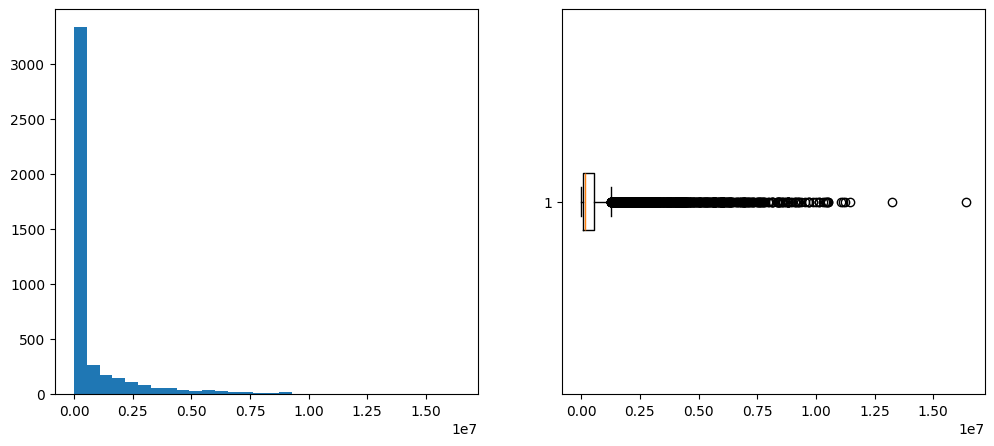

In [ ]:
#Ambil hanya transaksi expense
new_expense = df_new[df_new['transaction_type'] == 'expense']

#Cek skewness
print(new_expense['amount_idr'].skew())

#Visualisasi
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(new_expense['amount_idr'], bins=30)

plt.subplot(1,2,2)
plt.boxplot(new_expense['amount_idr'], vert=False)

plt.show()

In [ ]:
new_expense['amount_idr'].describe(percentiles=[0.9,0.95,0.99])

,amount_idr
count,4.455000e+03
mean,8.359753e+05
std,1.656773e+06
min,4.000000e+03
50%,1.670000e+05
90%,2.653800e+06
95%,4.411800e+06
99%,8.406900e+06
max,1.638000e+07


Variabel amount_idr pada transaksi expense memiliki distribusi positively skewed dengan nilai skewness sebesar 3.24. Hal ini menunjukkan sebagian besar transaksi memiliki nominal relatif kecil, sementara terdapat sejumlah kecil transaksi bernilai besar yang menyebabkan distribusi memanjang ke sisi kanan. Berdasarkan analisis persentil dan nilai maksimum, outlier yang muncul masih tergolong realistis sehingga tetap dipertahankan dalam analisis.

## Exploratory Data Analysis (EDA)

In [ ]:
#Cek struktur data
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5254 entries, 0 to 5253
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    5254 non-null   object        
 1   user_id           5254 non-null   object        
 2   date              5254 non-null   datetime64[ns]
 3   transaction_type  5254 non-null   object        
 4   category          5254 non-null   object        
 5   payment_mode      5254 non-null   object        
 6   location          5254 non-null   object        
 7   notes             5254 non-null   object        
 8   year_month        5254 non-null   period[M]     
 9   month             5254 non-null   int64         
 10  day_of_week       5254 non-null   object        
 11  is_weekend        5254 non-null   bool          
 12  year              5254 non-null   int64         
 13  amount_idr        5254 non-null   int64         
dtypes: bool(1), datetime64[n

In [ ]:
#Cek statistik deskriptif
df_new.describe(include="all")

,transaction_id,user_id,date,transaction_type,category,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,year,amount_idr
count,5254,5254,5254,5254,5254,5254,5254,5254,5254,5254.000000,5254,5254,5254.000000,5.254000e+03
unique,5254,150,NaN,2,13,5,11,265,48,NaN,7,2,NaN,NaN
top,T1955,U036,NaN,expense,makanan,qris,surabaya,bayar kontrakan,2024-09,NaN,Saturday,False,NaN,NaN
freq,1,55,NaN,4455,1144,1260,518,55,131,NaN,771,3722,NaN,NaN
mean,NaN,NaN,2023-01-12 08:29:46.981347584,NaN,NaN,NaN,NaN,NaN,NaN,6.547583,NaN,NaN,2022.530072,1.552686e+06
min,NaN,NaN,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,2021.000000,4.000000e+03
25%,NaN,NaN,2022-01-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,2022.000000,9.100000e+04
50%,NaN,NaN,2023-01-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,2023.000000,2.080000e+05
75%,NaN,NaN,2024-01-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,2024.000000,1.503250e+06
max,NaN,NaN,2024-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,2024.000000,2.990000e+07


**Insight:**
- Dataset terdiri dari 5254 transaksi dari 150 pengguna, menunjukkan data cukup besar untuk analisis dan pemodelan.
- Kategori makanan merupakan kategori dengan frekuensi tertinggi, sehingga berpotensi mendominasi model klasifikasi dibanding kategori lainnya.
- Mayoritas transaksi adalah pengeluaran (expense), yang menunjukkan pola penggunaan data lebih dominan pada aktivitas konsumsi dibanding pemasukan.
- Mean amount_idr jauh lebih besar dari median, yang menandakan terdapat indikasi outlier pada nilai transaksi karena rata-rata jauh lebih tinggi dibanding median. Namun, nilai transaksi menunjukkan distribusi yang tidak simetris, dengan beberapa nilai tinggi yang membentuk long-tail distribution. Hal ini umum terjadi dalam data keuangan dan tidak selalu menunjukkan kesalahan data.

In [ ]:
#Cek 5 data teratas
df_new.head()

,transaction_id,user_id,date,transaction_type,category,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,year,amount_idr
0,T0565,U052,2021-01-01,income,freelance,tunai,bandung,jasa edit video,2021-01,1,Friday,False,2021,5443000
1,T2465,U098,2021-01-01,expense,tempat_tinggal,tunai,bandung,bayar kos bulanan,2021-01,1,Friday,False,2021,1490000
2,T2971,U138,2021-01-01,expense,tempat_tinggal,bank_transfer,palembang,perpanjang sewa kos,2021-01,1,Friday,False,2021,1749000
3,T12231,U123,2021-01-01,expense,makanan,bank_transfer,jakarta,makan di food court,2021-01,1,Friday,False,2021,195000
4,T1657,U023,2021-01-02,expense,pendidikan,kartu,palembang,beli buku referensi,2021-01,1,Saturday,True,2021,143000


In [ ]:
df_new[['month','year','amount_idr']].corr()

,month,year,amount_idr
month,1.000000,0.021055,-0.015527
year,0.021055,1.000000,0.033537
amount_idr,-0.015527,0.033537,1.000000


Berdasarkan analisis korelasi, tidak ditemukan hubungan linear yang signifikan antara variabel waktu (bulan dan tahun) dengan nilai transaksi. Hal ini menunjukkan bahwa besarnya transaksi tidak dipengaruhi oleh faktor waktu secara langsung, melainkan kemungkinan lebih dipengaruhi oleh jenis transaksi atau kebutuhan pengguna.

In [ ]:
#Distribusi transaksi per category
df_new.groupby("category")["transaction_id"].count().sort_values(ascending=False)

,transaction_id
category,
makanan,1144
tempat_tinggal,875
transportasi,667
tagihan,529
hiburan,455
pendidikan,337
lainnya,269
kesehatan,221
investasi,162


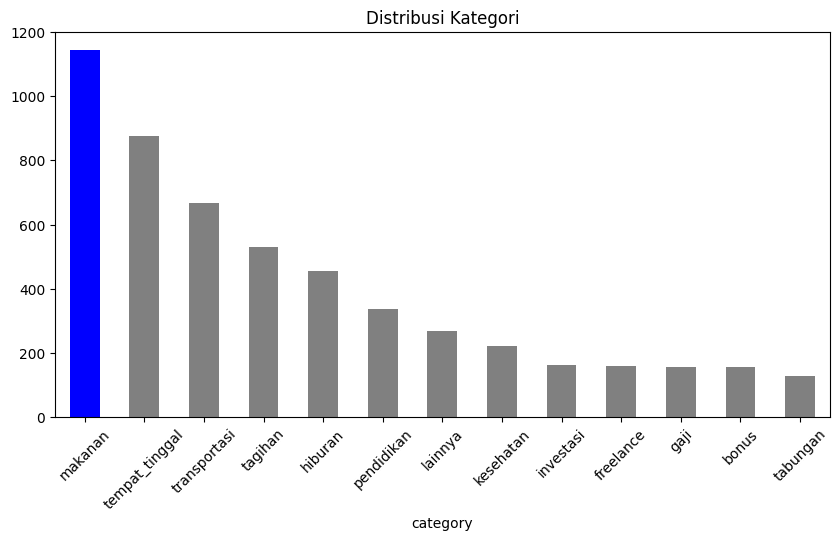

In [ ]:
#Distribusi category
cat_counts = df_new["category"].value_counts()

colors = ["gray"] * len(cat_counts)
colors[0] = "blue"

cat_counts.plot(kind="bar", color=colors, figsize=(10,5))
plt.title("Distribusi Kategori")
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Berdasarkan hasil pengelompokan data, kategori makanan memiliki jumlah transaksi tertinggi (1144 transaksi), diikuti oleh tempat_tinggal (875 transaksi) dan transportasi (667 transaksi). Hal ini menunjukkan bahwa transaksi didominasi oleh kategori kebutuhan utama dan aktivitas rutin. Sementara itu, kategori lain seperti gaji, bonus, dan tabungan memiliki jumlah transaksi yang relatif lebih rendah, sehingga kontribusinya terhadap total transaksi tidak terlalu signifikan.

In [ ]:
#Distribusi payment_mode
df_new["payment_mode"].value_counts()

,count
payment_mode,
qris,1260
tunai,1248
bank_transfer,1244
kartu,1231
ewallet,271


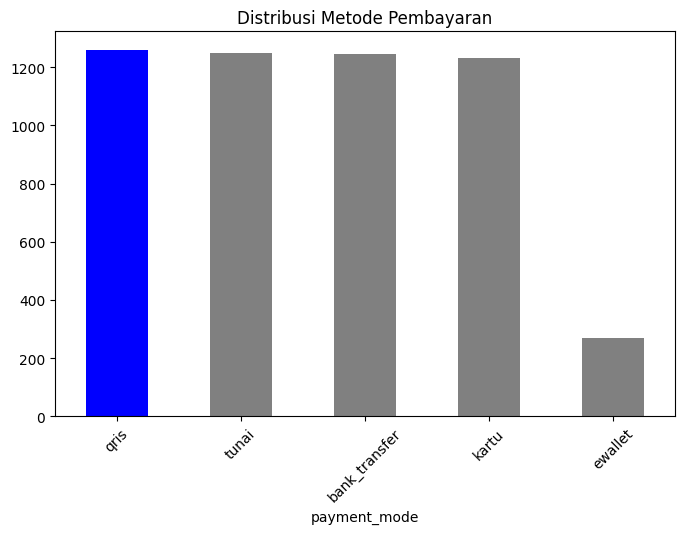

In [ ]:
pay_counts = df_new["payment_mode"].value_counts()

colors = ["gray"] * len(pay_counts)
colors[0] = "blue"

pay_counts.plot(kind="bar", color=colors, figsize=(8,5))
plt.title("Distribusi Metode Pembayaran")
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Berdasarkan hasil tersebut, dapat dilihat bahwa metode pembayaran qris, tunai, dan bank transfer memiliki jumlah transaksi yang hampir seimbang, dengan qris sedikit lebih tinggi dibandingkan metode lainnya. Hal ini menunjukkan bahwa penggunaan metode pembayaran dalam transaksi cukup merata dan tidak didominasi secara signifikan oleh satu metode saja.

In [ ]:
df_new["location"].value_counts()

,count
location,
surabaya,518
semarang,516
makassar,505
bandung,503
medan,484
jakarta,466
yogyakarta,465
balikpapan,464
denpasar,449


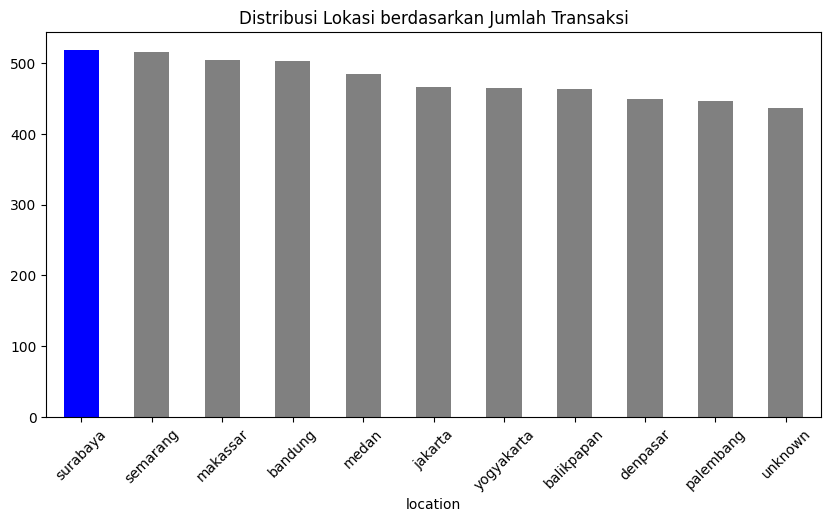

In [ ]:
#Distribusi Location
loc_counts = df_new["location"].value_counts()

colors = ["gray"] * len(loc_counts)
colors[0] = "blue"

loc_counts.plot(kind="bar", color=colors, figsize=(10,5))
plt.xticks(rotation=45)
plt.title("Distribusi Lokasi berdasarkan Jumlah Transaksi")
plt.show()

**Insight:**
- Berdasarkan hasil tersebut, dapat dilihat bahwa jumlah transaksi pada setiap lokasi relatif merata, dengan surabaya memiliki jumlah transaksi tertinggi yaitu 518 transaksi, diikuti oleh semarang berjumlah 516 transaksi, dan makassar berjumlah 505 transaksi. Hal ini menunjukkan bahwa aktivitas transaksi tersebar di berbagai lokasi tanpa perbedaan yang terlalu signifikan.

###**EDA untuk pertanyaan 1**

In [ ]:
#Membuat kolom periode bulanan
df_new['date'] = pd.to_datetime(df_new['date'])
df_new['year_month'] = df_new['date'].dt.to_period('M')

#Mengelompokkan income dan expense
income_expense = df_new.groupby(
    ['year_month', 'transaction_type']
)['amount_idr'].sum().unstack().fillna(0)

In [ ]:
#Mengubah semua nama kolom menjadi huruf kecil
income_expense = income_expense.rename(columns=str.lower)

#Mengambil kolom income dan expense, jika tidak ada dibuat kolom dengan nilai 0
income_expense['income'] = income_expense.get('income', 0)
income_expense['expense'] = income_expense.get('expense', 0)

In [ ]:
#Menghitung selisih antara expense dan income
income_expense['cashflow'] = income_expense['income'] - income_expense['expense']

#Menghitung rasio pengeluaran
income_expense['expense_ratio'] = income_expense['expense'] / income_expense['income'].replace(0, 1)

###**EDA untuk pertanyaan 2**

In [ ]:
#Mengambil data expense
df_new['transaction_type'] = df_new['transaction_type'].str.lower().str.strip()
df_expense = df_new[df_new['transaction_type'] == 'expense'].copy()

#Kolom year_month
df_expense['year_month'] = df_expense['date'].dt.to_period('M')

#Agregasi total pengeluaran perbulan
category_monthly = df_expense.groupby(
    ['year_month','category']
)['amount_idr'].sum().reset_index()

###**EDA untuk pertanyaan 3**

In [ ]:
#Mengambil tahun dari date
df_new['year'] = df_new['date'].dt.year

#Membuat tabel ringkasan
yearly_cashflow = df_new.pivot_table(
    index=['user_id','year'],
    columns='transaction_type',
    values='amount_idr',
    aggfunc='sum'
)

#Mengisi nilai kosong dengan 0
yearly_cashflow = yearly_cashflow.fillna(0)

#Hitung cashflow
yearly_cashflow['cashflow'] = yearly_cashflow['income'] - yearly_cashflow['expense']

#Ambil user top 5 per tahun dengan cashflow negatif
top_deficit = (
    yearly_cashflow[yearly_cashflow['cashflow'] < 0]
    .sort_values(['year', 'cashflow'])
    .groupby('year')
    .head(5)
)

top_deficit.reset_index()

transaction_type,user_id,year,expense,income,cashflow
0,U098,2021,26048000.0,954000.0,-25094000.0
1,U063,2021,20758000.0,0.0,-20758000.0
2,U119,2021,20404000.0,2622000.0,-17782000.0
3,U131,2021,16075000.0,76000.0,-15999000.0
4,U028,2021,16759000.0,3509000.0,-13250000.0
5,U113,2022,24335000.0,3876000.0,-20459000.0
6,U145,2022,20895000.0,904000.0,-19991000.0
7,U088,2022,17730000.0,378000.0,-17352000.0
8,U001,2022,16826000.0,0.0,-16826000.0
9,U117,2022,16644000.0,2955000.0,-13689000.0


###**EDA untuk pertanyaan 4**

In [ ]:
payment_usage = df_expense.groupby('payment_mode')['amount_idr'].sum().sort_values(ascending=False)

###**EDA untuk pertanyaan 5**

In [ ]:
#Mengambil pengeluaran dari 25% terbesar
threshold = df_expense["amount_idr"].quantile(0.75)

#Membuat kolom high_spending dengan nilai 0 dan 1
df_expense["high_spending"] = (df_expense["amount_idr"] >= threshold).astype(int)

In [ ]:
high_spending = df_expense[df_expense['high_spending'] == 1]
high_spending_time = high_spending.groupby('year_month')['amount_idr'].count()

##**Visualisasi Data**

###**Pertanyaan 1:** Bagaimana tren perbandingan antara income dan expense pengguna per bulan selama periode Januari 2021 hingga Desember 2024, serta pada bulan apa pengeluaran melebihi pemasukan?

In [ ]:
income_expense.index = income_expense.index.to_timestamp()
income_expense[income_expense['cashflow'] < 0]

transaction_type,expense,income,cashflow,expense_ratio
year_month,,,,
2021-04-01,63422000,37521000,-25901000,1.690307
2021-05-01,61928000,61017000,-911000,1.014930
2021-08-01,85121000,81751000,-3370000,1.041223
2021-09-01,71178000,43752000,-27426000,1.626851
2021-11-01,79842000,39927000,-39915000,1.999699
2021-12-01,56194000,55339000,-855000,1.015450
2022-03-01,123811000,70834000,-52977000,1.747904
2022-05-01,75164000,49530000,-25634000,1.517545
2022-10-01,70099000,50171000,-19928000,1.397202


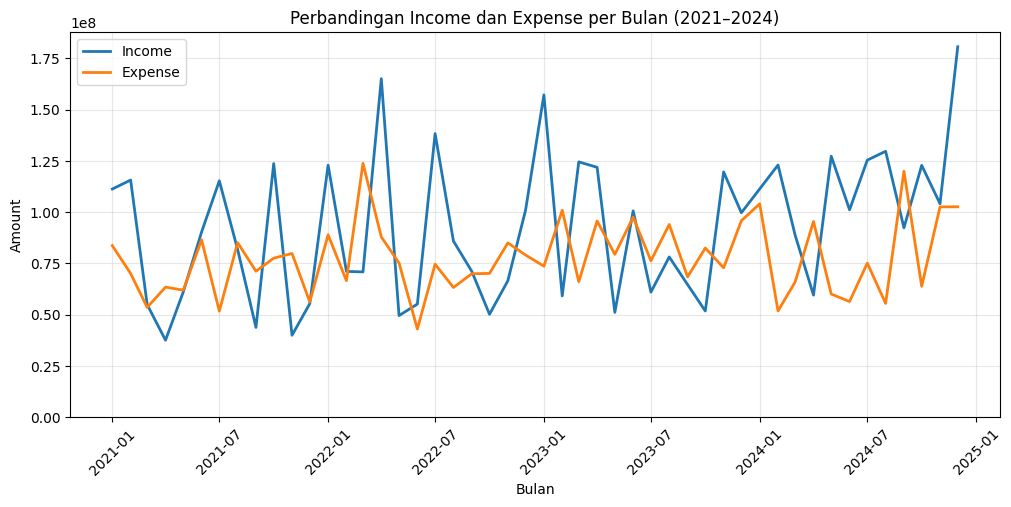

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(income_expense.index, income_expense['income'], label='Income', linewidth=2)
plt.plot(income_expense.index, income_expense['expense'], label='Expense', linewidth=2)

plt.title("Perbandingan Income dan Expense per Bulan (2021–2024)")
plt.xlabel("Bulan")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.ylim(bottom=0)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

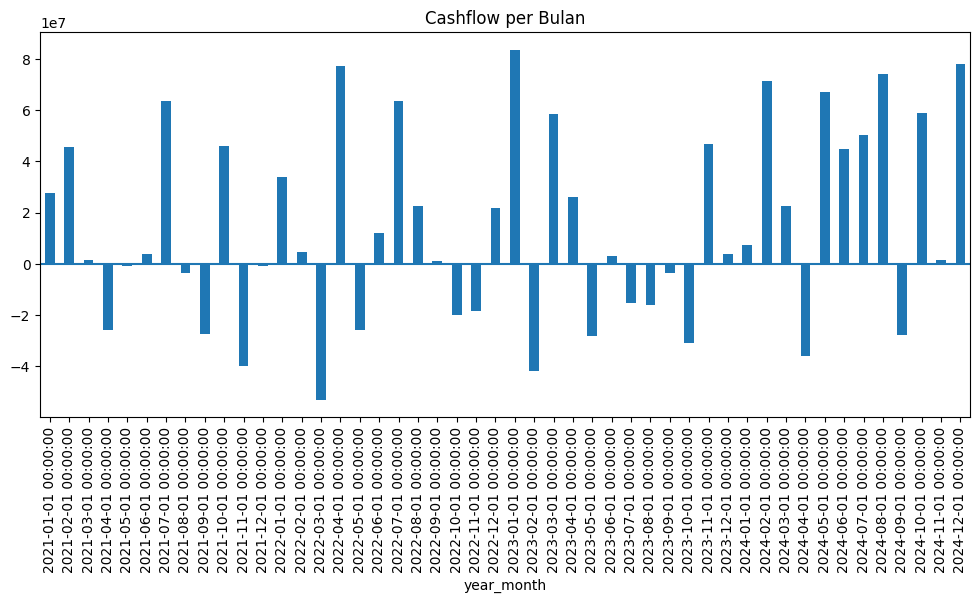

In [ ]:
income_expense['cashflow'].plot(kind='bar', figsize=(12,5))
plt.title("Cashflow per Bulan")
plt.axhline(0)
plt.show()

**Insight:**
- Grafik menunjukkan bahwa baik income maupun expense mengalami fluktuasi sepanjang periode 2021-2024, yang mengindikasikan bahwa kondisi keuangan tidak stabil dan dipengaruhi oleh variasi transaksi setiap bulan.
- Pada beberapa periode, garis expense berada di atas income, yang menunjukkan terjadinya defisit (pengeluaran lebih besar dari pemasukan). Berdasarkan hasil analisis, kondisi defisit terjadi pada:
1. Tahun 2021: April, Mei, Agustus, September, November, dan Desember
2. Tahun 2022: Maret, Mei, Oktober, dan November
3. Tahun 2023: Februari, Mei, Juli, Agustus, September, dan Oktober
4. Tahun 2024: April, dan September
- Income terlihat lebih fluktuatif dibandingkan expense, dengan beberapa lonjakan signifikan pada periode tertentu. Sementara itu, expense juga mengalami perubahan dari waktu ke waktu, namun relatif lebih konsisten dibandingkan income.
- Cashflow bulanan menunjukkan fluktuasi yang cukup besar, dengan beberapa bulan mengalami surplus dan beberapa bulan lainnya mengalami defisit hingga ratusan juta rupiah. Hal ini menunjukkan bahwa kondisi keuangan belum stabil karena masih terdapat periode ketika pengeluaran melebihi pemasukan.

###**Pertanyaan 2:** Bagaimana distribusi persentase pengeluaran berdasarkan kategori setiap bulan selama periode Januari 2021 hingga Desember 2024, dan kategori apa yang secara konsisten menjadi penyumbang terbesar?

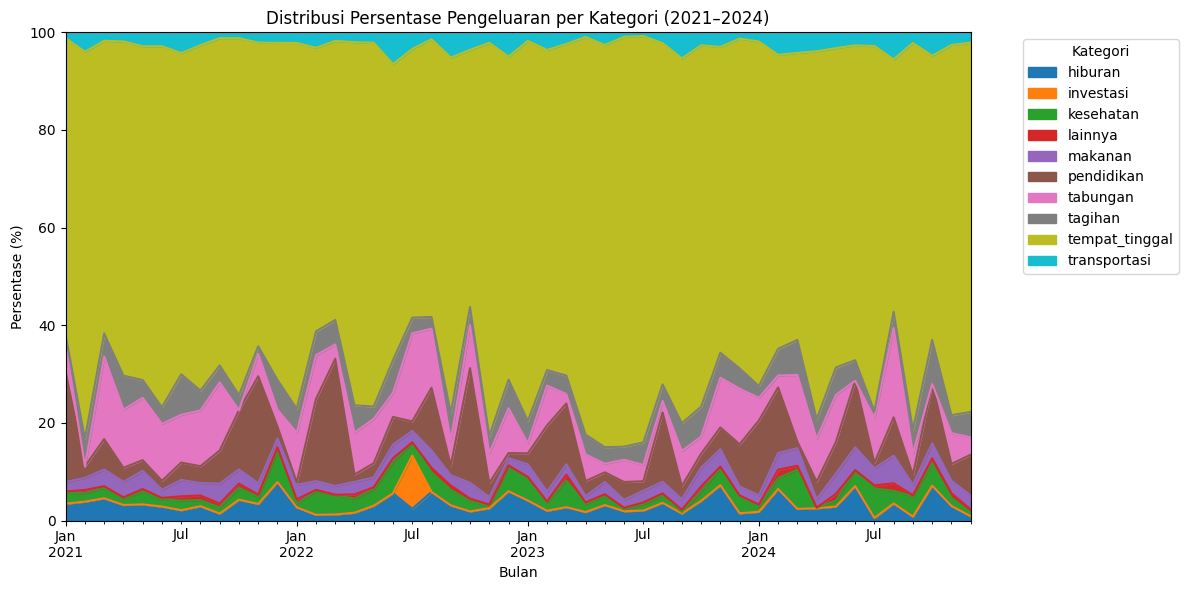

,0
category,
tempat_tinggal,68.831327
tabungan,7.272433
pendidikan,7.215020
tagihan,4.456323
hiburan,3.232661
transportasi,2.803177
makanan,2.693699
kesehatan,2.669929
lainnya,0.597689


In [ ]:
#Membuat pivot berdasarkan year_month, category, dan amount
category_pivot = category_monthly.pivot(
    index='year_month',
    columns='category',
    values='amount_idr'
).fillna(0)

category_presentase = category_pivot.div(category_pivot.sum(axis=1), axis=0) * 100

category_presentase.plot(
    kind='area',
    stacked=True,
    figsize=(12,6)
)

plt.title("Distribusi Persentase Pengeluaran per Kategori (2021–2024)")
plt.xlabel("Bulan")
plt.ylabel("Persentase (%)")
plt.legend(title="Kategori", bbox_to_anchor=(1.05,1))
plt.ylim(0,100)
plt.tight_layout()
plt.show()

#Rata-rata presentase pengeluaran per category
category_presentase.mean().sort_values(ascending=False)

**Insight:**
- Berdasarkan analisis distribusi persentase pengeluaran selama periode Januari 2021 hingga Desember 2024, terlihat bahwa kategori tempat_tinggal merupakan penyumbang terbesar secara signifikan terhadap total pengeluaran, dengan kontribusi mencapai sekitar 68.83%.
- Nilai ini jauh lebih tinggi dibandingkan kategori lainnya, yang menunjukkan adanya dominasi yang sangat kuat dari pengeluaran terkait tempat tinggal.
- Kategori lain seperti tabungan (7.27%) dan pendidikan (7.21%) memiliki kontribusi yang jauh lebih kecil, sementara kategori lainnya seperti makanan, transportasi, dan hiburan masing-masing hanya menyumbang kurang dari 5% dari total pengeluaran.
- Pola ini menunjukkan bahwa sebagian besar pengeluaran pengguna dialokasikan untuk kebutuhan tempat tinggal, sehingga distribusi pengeluaran bersifat tidak merata (skewed distribution).
- Selain itu, kategori tempat_tinggal secara konsisten menjadi penyumbang terbesar pada hampir setiap bulan selama periode pengamatan.

### **Pertanyaan 3:** Sejauh mana setiap user_id mengalami kondisi defisit (cashflow negatif) selama periode Januari 2021 hingga Desember 2024, berdasarkan selisih total income dan expense, dan berapa proporsi user yang mengalami kondisi tersebut?

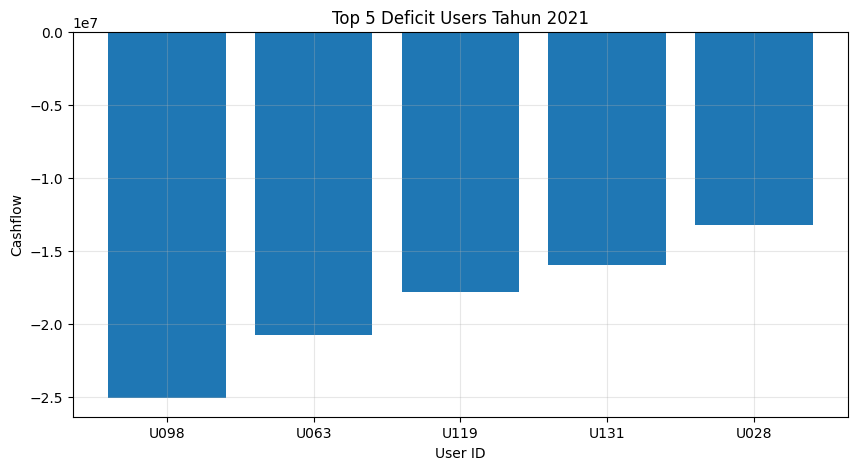

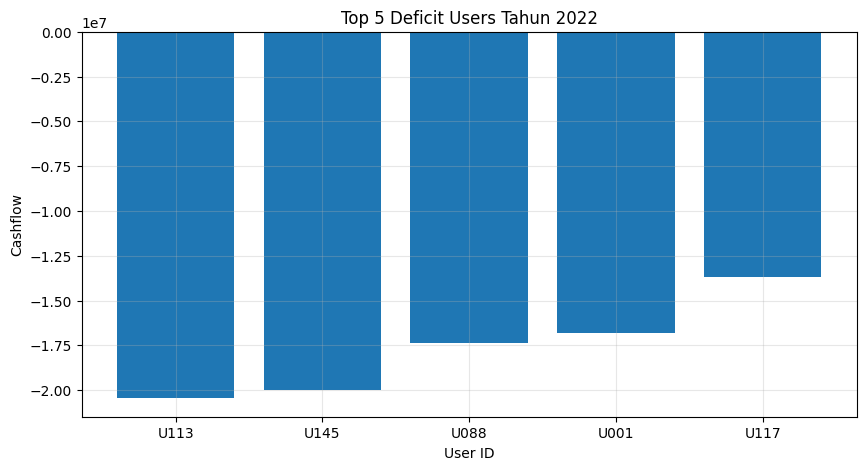

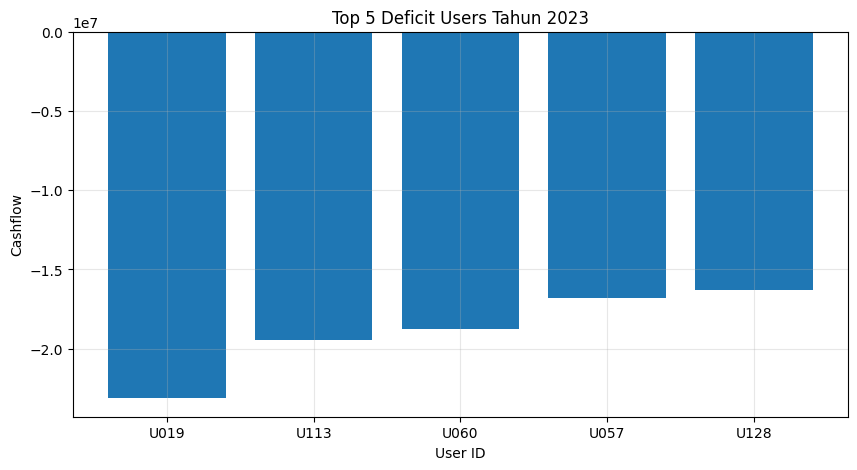

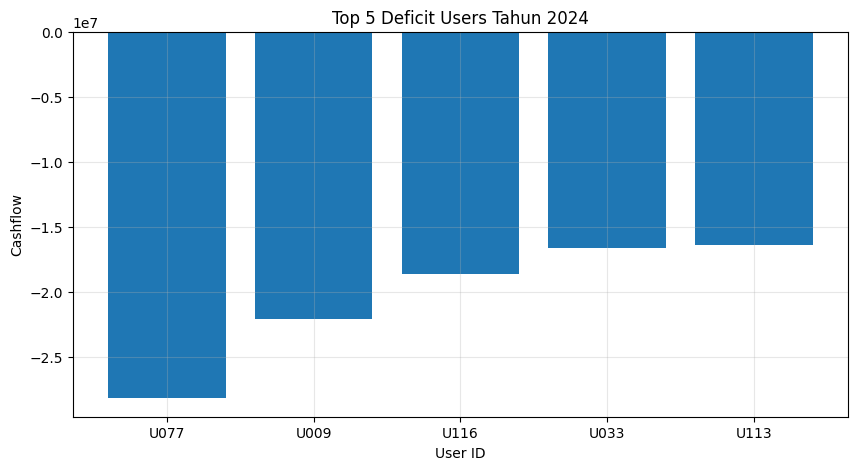

In [ ]:
#Menentukan top 5 pengguna dengan cashflow negatif terbesar setiap tahun
top_deficit = (
    yearly_cashflow
    .reset_index()
    .query('cashflow < 0')
    .sort_values(['year', 'cashflow'])
    .groupby('year')
    .head(5)
)

for year, temp in top_deficit.groupby('year'):
    plt.figure(figsize=(10,5))

    plt.bar(temp['user_id'], temp['cashflow'])

    plt.title(f"Top 5 Deficit Users Tahun {year}")
    plt.xlabel("User ID")
    plt.ylabel("Cashflow")

    plt.xticks(rotation=0)
    plt.grid(alpha=0.3)

    plt.show()

In [ ]:
#Proporsi pengguna yang deficit per tahun
df_reset = yearly_cashflow.reset_index()
result = (
    df_reset
    .groupby('year')
    .agg(
        total_user=('user_id', 'nunique'),
        deficit_user=('cashflow', lambda x: (x < 0).sum())
    )
)

#Hitung presentase
result['proporsi_deficit (%)'] = (result['deficit_user'] / result['total_user']) * 100

result.reset_index()

,year,total_user,deficit_user,proporsi_deficit (%)
0,2021,150,86,57.333333
1,2022,150,84,56.000000
2,2023,150,75,50.000000
3,2024,150,77,51.333333


**Insight:**
- Berdasarkan analisis cashflow per user pada periode 2021-2024, seluruh user yang termasuk dalam kelompok *top deficit users* memiliki cashflow negatif, yaitu total pengeluaran (*expense*) tercatat lebih besar dibandingkan total pemasukan (*income*) yang tercatat pada dataset di tahun tersebut.
- Berdasarkan visualisasi, nilai defisit terbesar setiap tahun berada pada kisaran puluhan juta rupiah. Pada tahun 2021, defisit terbesar dialami oleh user **U098** dengan nilai sekitar **-25 juta rupiah**. Pada tahun 2022, defisit terbesar dialami oleh **U113** dengan nilai sekitar **-20 juta rupiah**. Tahun 2023 menunjukkan defisit sekitar **-23 juta rupiah** pada user **U019**, sedangkan tahun 2024 menunjukkan defisit terbesar sekitar **-28 juta rupiah** pada user **U077**.
- Nilai defisit antar user menunjukkan fluktuasi dari tahun ke tahun dan tidak membentuk pola peningkatan yang konsisten. Beberapa user juga muncul lebih dari satu kali pada periode berbeda, seperti **U113**, yang mengindikasikan adanya pola cashflow negatif berulang berdasarkan transaksi yang tercatat.
- Berdasarkan proporsi user defisit, lebih dari separuh user memiliki cashflow negatif pada sebagian besar tahun pengamatan, yaitu 57,33% pada 2021, 56% pada 2022, 50% pada 2023, dan 51,33% pada 2024.
- Namun, hasil ini perlu diinterpretasikan secara hati-hati karena analisis hanya didasarkan pada transaksi yang berhasil dicatat dalam dataset. Cashflow negatif tidak selalu menunjukkan kondisi keuangan sebenarnya dari pengguna, karena dimungkinkan terdapat transaksi pemasukan maupun pengeluaran yang tidak direkap atau tidak tercatat oleh user. Oleh sebab itu, hasil analisis lebih tepat menggambarkan pola transaksi yang tercatat dalam sistem dibandingkan kondisi finansial riil pengguna secara keseluruhan.


### **Pertanyaan 4:** Metode pembayaran apa yang paling sering digunakan selama periode Januari 2021 hingga Desember 2024, serta bagaimana kontribusinya terhadap total dan rata-rata nilai transaksi?


In [ ]:
payment_summary = pd.DataFrame({
    'frequency': df_expense['payment_mode'].value_counts(),
    'total_amount': df_expense.groupby('payment_mode')['amount_idr'].sum(),
    'avg_amount': df_indonesia.groupby('payment_mode')['amount_idr'].mean()
})

payment_summary = payment_summary.sort_values(by='frequency', ascending=False)
payment_summary

,frequency,total_amount,avg_amount
payment_mode,,,
bank_transfer,1066,826082000,107763.932460
qris,1061,949717000,146434.915460
tunai,1059,865437000,100062.937348
kartu,1049,917922000,124349.584777
ewallet,220,165112000,148203.550443


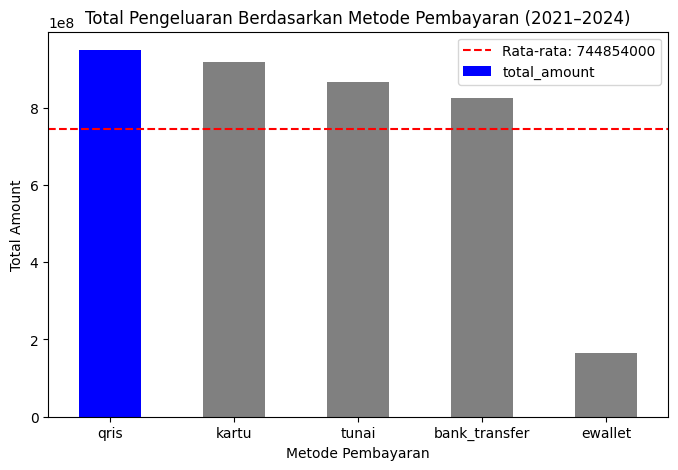

In [ ]:
payment_summary = payment_summary.sort_values(by='total_amount', ascending=False)
colors = ["gray"] * len(payment_summary)
colors[0] = "blue"

ax = payment_summary['total_amount'].plot(
    kind='bar',
    figsize=(8,5),
    color=colors
)

avg_total = payment_summary['total_amount'].mean()

plt.axhline(
    y=avg_total,
    color='red',
    linestyle='--',
    label=f'Rata-rata: {avg_total:.0f}')

plt.title("Total Pengeluaran Berdasarkan Metode Pembayaran (2021–2024)")
plt.xlabel("Metode Pembayaran")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.legend()
plt.show()

**Insight:**
- Selama periode 2021-2024, metode pembayaran yang paling sering digunakan adalah **bank transfer** dengan 1.066 transaksi, disusul QRIS dan tunai dengan jumlah transaksi yang hampir sama.
- Meskipun bukan yang paling sering digunakan, **QRIS** memiliki total nilai transaksi terbesar, yaitu sekitar **949,7 juta rupiah**, sehingga menjadi metode pembayaran dengan kontribusi transaksi tertinggi.
- Metode **ewallet** memiliki frekuensi penggunaan paling rendah, tetapi rata-rata nominal transaksinya paling tinggi, yaitu sekitar **148 ribu rupiah** per transaksi.
- Secara umum, metode pembayaran digital seperti QRIS dan kartu cenderung digunakan untuk transaksi bernilai lebih besar dibandingkan tunai dan bank transfer.


###**Pertanyaan 5:** Bagaimana pola kemunculan transaksi bernilai tinggi (high spending), yang didefinisikan sebagai transaksi di atas persentil ke-75, berdasarkan waktu selama periode Januari 2021 hingga Desember 2024?

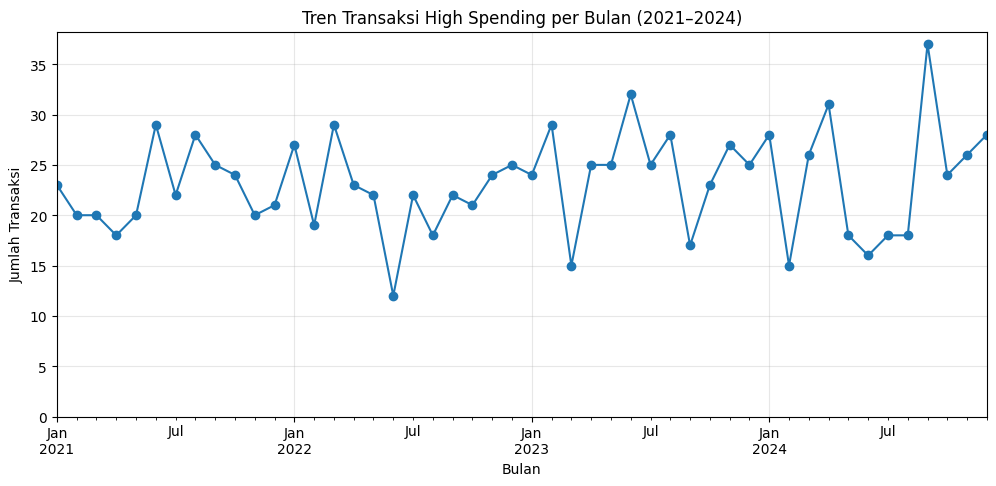

In [ ]:
high_spending_time.plot(figsize=(12,5), marker='o')

plt.title("Tren Transaksi High Spending per Bulan (2021–2024)")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=0)
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.show()

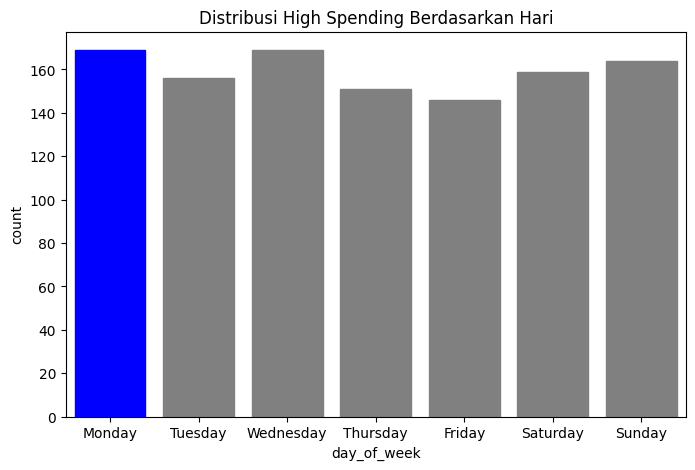

In [ ]:
plt.figure(figsize=(8,5))

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ax = sns.countplot(
    data=high_spending,
    x='day_of_week',
    order=order
)

#Ambil index dengan nilai tertinggi
counts_high_spending = high_spending['day_of_week'].value_counts().reindex(order)
max_idx = counts_high_spending.values.argmax()

for i, bar in enumerate(ax.patches):
    if i == max_idx:
        bar.set_color('blue')
    else:
        bar.set_color('gray')

plt.title("Distribusi High Spending Berdasarkan Hari")
plt.xticks(rotation=0)
plt.show()

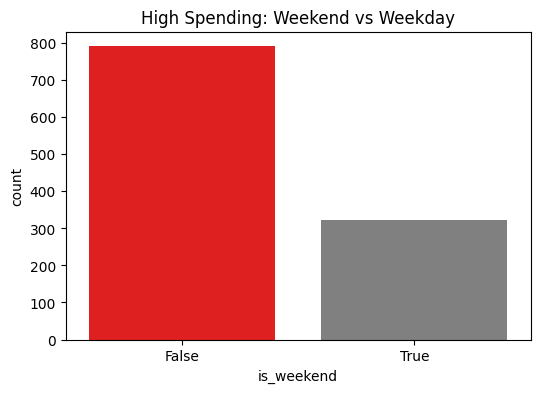

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=high_spending,
    x='is_weekend',
    hue='is_weekend',
    palette={False: 'red', True: 'gray'},
    legend=False
)

plt.title("High Spending: Weekend vs Weekday")
plt.show()

**Insight:**
- Transaksi high spending terjadi di seluruh hari dalam seminggu dengan distribusi yang relatif merata, meskipun terdapat sedikit peningkatan pada hari tertentu seperti Senin, Rabu dan Minggu.
- Mayoritas transaksi high spending justru terjadi pada hari kerja (weekday) dibandingkan akhir pekan (weekend).
- Meskipun akhir pekan sering dianggap dengan aktivitas konsumtif, data menunjukkan bahwa transaksi bernilai tinggi tidak secara signifikan terkonsentrasi pada weekend.

##**Conclusion:**

Berdasarkan analisis transaksi periode Januari 2021-Desember 2024, kondisi keuangan pengguna cenderung fluktuatif dengan beberapa periode mengalami surplus maupun defisit. Income terlihat lebih berubah-ubah dibandingkan expense, sedangkan pengeluaran relatif stabil karena didominasi kebutuhan rutin seperti tempat tinggal dan makanan.

Analisis per user menunjukkan bahwa sekitar 50%-57% pengguna mengalami cashflow negatif setiap tahun berdasarkan transaksi yang tercatat. Namun, hasil ini perlu diinterpretasikan secara hati-hati karena dimungkinkan terdapat transaksi yang tidak direkap oleh pengguna.

Dalam metode pembayaran, bank transfer menjadi metode yang paling sering digunakan, sedangkan QRIS memiliki total nilai transaksi terbesar. Sementara itu, ewallet memiliki rata-rata nominal transaksi tertinggi meskipun frekuensi penggunaannya paling rendah.

Selain itu, transaksi high spending tersebar cukup merata sepanjang minggu dan lebih banyak terjadi pada hari kerja dibandingkan akhir pekan. Secara keseluruhan, pola transaksi pengguna lebih mencerminkan kebutuhan finansial rutin dibandingkan pengaruh waktu atau pola musiman tertentu.


In [ ]:
df_new.head()

,transaction_id,user_id,date,transaction_type,category,payment_mode,location,notes,year_month,month,day_of_week,is_weekend,year,amount_idr
0,T0565,U052,2021-01-01,income,freelance,tunai,bandung,jasa edit video,2021-01,1,Friday,False,2021,5443000
1,T2465,U098,2021-01-01,expense,tempat_tinggal,tunai,bandung,bayar kos bulanan,2021-01,1,Friday,False,2021,1490000
2,T2971,U138,2021-01-01,expense,tempat_tinggal,bank_transfer,palembang,perpanjang sewa kos,2021-01,1,Friday,False,2021,1749000
3,T12231,U123,2021-01-01,expense,makanan,bank_transfer,jakarta,makan di food court,2021-01,1,Friday,False,2021,195000
4,T1657,U023,2021-01-02,expense,pendidikan,kartu,palembang,beli buku referensi,2021-01,1,Saturday,True,2021,143000


##**Dataset klasifikasi**

In [ ]:
#Membuat dataset khusus modeling klasifikasi
df_klasifikasi = df_new.copy()

list(df_klasifikasi.columns)

['transaction_id',
 'user_id',
 'date',
 'transaction_type',
 'category',
 'payment_mode',
 'location',
 'notes',
 'year_month',
 'month',
 'day_of_week',
 'is_weekend',
 'year',
 'amount_idr']

In [ ]:
#Ambil kolom yang diperlukan saja
df_klasifikasi = df_klasifikasi[['notes', 'category', 'amount_idr', 'month','is_weekend','day_of_week']].dropna().copy()

df_klasifikasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5254 entries, 0 to 5253
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   notes        5254 non-null   object
 1   category     5254 non-null   object
 2   amount_idr   5254 non-null   int64 
 3   month        5254 non-null   int64 
 4   is_weekend   5254 non-null   bool  
 5   day_of_week  5254 non-null   object
dtypes: bool(1), int64(2), object(3)
memory usage: 210.5+ KB


In [94]:
#Membersihkan teks notes
df_klasifikasi['notes'] = df_klasifikasi['notes'].str.lower()
df_klasifikasi['notes'] = df_klasifikasi['notes'].str.replace('[^a-zA-Z ]', '', regex=True)
df_klasifikasi['notes'] = df_klasifikasi['notes'].str.replace(r'\s+', ' ', regex=True).str.strip()

df_klasifikasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5254 entries, 0 to 5253
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   notes        5254 non-null   object
 1   category     5254 non-null   object
 2   amount_idr   5254 non-null   int64 
 3   month        5254 non-null   int64 
 4   is_weekend   5254 non-null   bool  
 5   day_of_week  5254 non-null   object
dtypes: bool(1), int64(2), object(3)
memory usage: 210.5+ KB


##**Dataset prediksi**

In [ ]:
#Membuat dataset khusus modeling prediksi
df_prediksi = df_new.copy()
df_prediksi = df_prediksi[df_prediksi['transaction_type'] == 'expense']

list(df_prediksi.columns)

['transaction_id',
 'user_id',
 'date',
 'transaction_type',
 'category',
 'payment_mode',
 'location',
 'notes',
 'year_month',
 'month',
 'day_of_week',
 'is_weekend',
 'year',
 'amount_idr']

In [ ]:
#Memilih kolom yang sesuai
df_prediksi = df_prediksi[
    ['category', 'month', 'day_of_week', 'is_weekend', 'year', 'amount_idr']
].dropna().copy()

df_prediksi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4455 entries, 1 to 5253
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     4455 non-null   object
 1   month        4455 non-null   int64 
 2   day_of_week  4455 non-null   object
 3   is_weekend   4455 non-null   bool  
 4   year         4455 non-null   int32 
 5   amount_idr   4455 non-null   int64 
dtypes: bool(1), int32(1), int64(2), object(2)
memory usage: 195.8+ KB


In [ ]:
#Mengubah data kategorikal (category) menjadi numerik (One hot Encoding)
df_prediksi = pd.get_dummies(df_prediksi, columns=['category','day_of_week'])

In [ ]:
#Mengubah nilai boolean (True/False) menjadi numerik (1/0)
df_prediksi['is_weekend'] = df_prediksi['is_weekend'].astype(int)

df_prediksi['month'] = df_prediksi['month'].astype(int)
df_prediksi.head()

,month,is_weekend,year,amount_idr,category_hiburan,category_investasi,category_kesehatan,category_lainnya,category_makanan,category_pendidikan,...,category_tagihan,category_tempat_tinggal,category_transportasi,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
1,1,0,2021,1490000,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2,1,0,2021,1749000,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
3,1,0,2021,195000,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,1,1,2021,143000,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
5,1,1,2021,29000,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
df_prediksi.dtypes

,0
month,int64
is_weekend,int64
year,int32
amount_idr,int64
category_hiburan,bool
category_investasi,bool
category_kesehatan,bool
category_lainnya,bool
category_makanan,bool
category_pendidikan,bool


In [ ]:
df_prediksi = df_prediksi.astype(int)
df_prediksi.dtypes

,0
month,int64
is_weekend,int64
year,int64
amount_idr,int64
category_hiburan,int64
category_investasi,int64
category_kesehatan,int64
category_lainnya,int64
category_makanan,int64
category_pendidikan,int64


In [ ]:
#Membuat Data Dictionary

data_dictionary = pd.DataFrame({
    'Column': [
        'transaction_id',
        'user_id',
        'date',
        'transaction_type',
        'category',
        'payment_mode',
        'location',
        'notes',
        'year_month',
        'month',
        'day_of_week',
        'is_weekend',
        'year',
        'amount_idr'
    ],

    'Data Type': [
        'string',
        'string',
        'datetime',
        'categorical',
        'categorical',
        'categorical',
        'categorical',
        'text',
        'period[M]',
        'integer',
        'categorical',
        'boolean',
        'integer',
        'integer'
    ],

    'Description': [
        'ID unik untuk setiap transaksi',
        'ID pengguna yang melakukan transaksi',
        'Tanggal transaksi dilakukan',
        'Jenis transaksi: income atau expense',
        'Kategori transaksi',
        'Metode pembayaran (tunai, transfer, kartu, dll)',
        'Lokasi transaksi dilakukan',
        'Catatan atau deskripsi transaksi',
        'Periode transaksi dalam format tahun-bulan',
        'Bulan transaksi (1–12)',
        'Hari transaksi dalam seminggu',
        'Menunjukkan apakah transaksi terjadi di akhir pekan',
        'Tahun transaksi',
        'Nilai transaksi dalam Rupiah (IDR)'
    ]
})

data_dictionary

,Column,Data Type,Description
0,transaction_id,string,ID unik untuk setiap transaksi
1,user_id,string,ID pengguna yang melakukan transaksi
2,date,datetime,Tanggal transaksi dilakukan
3,transaction_type,categorical,Jenis transaksi: income atau expense
4,category,categorical,Kategori transaksi
5,payment_mode,categorical,"Metode pembayaran (tunai, transfer, kartu, dll)"
6,location,categorical,Lokasi transaksi dilakukan
7,notes,text,Catatan atau deskripsi transaksi
8,year_month,period[M],Periode transaksi dalam format tahun-bulan
9,month,integer,Bulan transaksi (1–12)


## Simpan berkas dataset bersih

In [ ]:
#Menyimpan berkas data yang telah dibersihkan
df_new.to_csv("cleaned_finance_data.csv", index=False)

#Menyimpan data_dictionary
data_dictionary.to_excel("data_dictionary.xlsx", index=False)

#Menyimpan berkas data siap diproses oleh model
df_klasifikasi.to_csv("klasifikasi_dataset.csv", index=False)
df_prediksi.to_csv("prediksi_dataset.csv", index=False)

**Catatan:**

- Pada klasifikasi_dataset masih menyertakan kolom target `category` karena akan digunakan pada tahap pemodelan klasifikasi. Pada proses training, kolom `category` akan dipisahkan dari fitur (X) dan digunakan sebagai target (y) sehingga tidak terjadi data leakage.
- Pada prediksi_dataset juga masih menyertakan kolom target `amount_idr` untuk keperluan pemodelan prediksi. Pada tahap training, kolom `amount_idr` akan dipisahkan dari fitur (X) dan digunakan sebagai target (y) sehingga informasi target tidak ikut digunakan sebagai fitur masukan model.